## __Aprendizaje no supervisado__

__Profesor__: Anthony D. Cho

__Ayudante__: Luis Oliveros

__Asunto__: Clustering

__Evaluación__: Actividad 02

***

**Estudiantes**: (Recordar colocar los RUTs, nombres y apellidos)

* 20.605.498-0 Sergio Meneses
* 20.984.237-8 Vicente Yañez


#### Instrucciones
* La actividad puede ser realizada en grupo de hasta 3 personas.
* Por favor responder en este mismo notebook.
* Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo Actividad_02_Akina_Nosta.ipynb
* Una vez completada la tarea, uno de los integrantes debe subir al enlace habilitada en el Webcursos.

+ __Fecha de entrega:__ Hasta el miércoles 08 de octubre de 2025, 23:59 hrs chile.

#### Objetivo de la actividad

Aplicar las técnicas aprendidas de clustering en datos suministrados.

## Librerias

In [82]:
from pandas import read_csv

## Agregar las librerias que van a usar


## Dataset:

Este conjunto de datos contiene registros de compras de clientes en un retail particular, donde tiene 11 features y 2000 registros.

* La data está completamente disponible en el [Kaggle - Retail Sales Dataset)](https://www.kaggle.com/datasets/najir0123/retail-sales-dataset?resource=download) que se puede descargar gratuitamente. 

<center>
    <img src='https://www.advotics.com/wp-content/uploads/2022/09/header-3-1.png' width=800>
<center>

### Carga de datos

In [83]:
dataset = read_csv('https://raw.githubusercontent.com/adoc-box/Datasets/refs/heads/main/Retail%20Sales.csv', 
                   parse_dates=['sale_date'])
print('(shape) dataset: {}'.format(dataset.shape))
dataset.head()

(shape) dataset: (2000, 11)


,transactions_id,sale_date,sale_hour,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,8,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,8,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [84]:
## Descripción de los datos
dataset.describe(include='all')

,transactions_id,sale_date,sale_hour,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
count,2000.000000,2000,2000.000000,2000.000000,2000,1990.000000,2000,1997.000000,1997.000000,1997.000000,1997.000000
unique,NaN,NaN,NaN,NaN,2,NaN,3,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,Female,NaN,Clothing,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,1020,NaN,702,NaN,NaN,NaN,NaN
mean,1000.500000,2023-02-16 22:10:33.600000,15.966000,66.341500,NaN,41.343216,NaN,2.512769,180.117677,95.023886,456.544817
min,1.000000,2022-01-01 00:00:00,6.000000,1.000000,NaN,18.000000,NaN,1.000000,25.000000,6.250000,25.000000
25%,500.750000,2022-09-23 00:00:00,11.000000,24.000000,NaN,29.000000,NaN,1.000000,30.000000,13.000000,60.000000
50%,1000.500000,2023-01-12 12:00:00,18.000000,69.000000,NaN,42.000000,NaN,3.000000,50.000000,27.500000,150.000000
75%,1500.250000,2023-09-14 00:00:00,20.000000,102.000000,NaN,53.000000,NaN,4.000000,300.000000,147.000000,900.000000
max,2000.000000,2023-12-31 00:00:00,23.000000,155.000000,NaN,64.000000,NaN,4.000000,500.000000,620.000000,2000.000000


In [85]:
dataset.info()  
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transactions_id  2000 non-null   int64         
 1   sale_date        2000 non-null   datetime64[ns]
 2   sale_hour        2000 non-null   int64         
 3   customer_id      2000 non-null   int64         
 4   gender           2000 non-null   object        
 5   age              1990 non-null   float64       
 6   category         2000 non-null   object        
 7   quantiy          1997 non-null   float64       
 8   price_per_unit   1997 non-null   float64       
 9   cogs             1997 non-null   float64       
 10  total_sale       1997 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(3), object(2)
memory usage: 172.0+ KB


,transactions_id,sale_date,sale_hour,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,8,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,8,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


## Paso 1: Selección, limpieza y pre-procesamiento de los features

En este paso, indique cuáles features van a considerarse para realizar el clustering y aplicar algunas transformaciones y escalados que consideren ser necesarios.

__Por ejemplo__, recuerde que ciertos algoritmos necesitan que los datos estén en la misma escala, y esto no necesariamente se cumple.

__Respuesta__:

In [86]:

print(dataset.dtypes)

transactions_id             int64
sale_date          datetime64[ns]
sale_hour                   int64
customer_id                 int64
gender                     object
age                       float64
category                   object
quantiy                   float64
price_per_unit            float64
cogs                      float64
total_sale                float64
dtype: object


## **Respuesta pregunta 1**
- No se puede considerar **"sale_date"** porque es una variable de tipo *datetime*.
- Tampoco se pueden considerar **"gender"** y **"category"**, porque son variables categóricas de tipo *object*.
- Tampoco se van a considerar la variables indentificadores como **"transactions_id"** y **"customer_id"** 
- Considera que todos los Nan se van a eliminar por un tema de simplicidad, entendiendo que se podria imputar por la moda. 

In [87]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# seleccionar solo variables numéricas y eliminar filas con NaN
columns_to_scale = ['sale_hour', 'age', 'quantiy','price_per_unit','cogs','total_sale']
dataset_cleaned = dataset[columns_to_scale].dropna()

# Escalar los datos
scaler = StandardScaler()
data_scaled_array = scaler.fit_transform(dataset_cleaned)
data_scaled = pd.DataFrame(data_scaled_array, columns=columns_to_scale)

data_scaled.head()  


,sale_hour,age,quantiy,price_per_unit,cogs,total_sale
0,-1.171656,-0.025718,0.429286,0.634000,0.278013,0.789901
1,-0.976756,0.340336,0.429286,1.690002,0.409159,1.859951
2,-1.171656,-0.098928,1.312301,0.634000,-0.090834,1.324926
3,-1.561456,-0.025718,0.429286,0.634000,0.278013,0.789901
4,-1.561456,0.340336,0.429286,1.690002,1.146855,1.859951


## Paso 2: Aplicación de Clustering

En este paso, aplique alguna de las técnica de clustering vistas en el curso. Pruebe distintas alternativas. si es pertinente realice calibración de los hiperparámetros (número de clústeres, métrica a usar, etc.)

**Nota**: Describa en la ventana siguiente las técnicas que probó, así como el modelo seleccionado (con sus valores de hiperparámetros finales). En las siguientes ventanas, coloque los códigos utilizados del mejor modelo para poder reproducir el resultado final. (Ojo: no necesita poner *todos* los códigos de todos los métodos que probó. Basta con aquellos relacionados con el modelo final seleccionado).

__Respuesta__:

## ** Respuesta
## Clustering con K-Means y DBSCAN

En este análisis aplicamos dos técnicas de **clustering** sobre un dataset previamente escalado y reducido a dos dimensiones mediante **PCA**. Ambas técnicas permiten agrupar los datos en clústeres y evaluar la calidad del agrupamiento mediante el **Silhouette Score**.

---

### K-Means

**Pasos principales:**

1. **Reducción de dimensionalidad:**  
   Se aplica PCA para obtener dos componentes principales (`PC1` y `PC2`), facilitando visualización y clustering.

2. **Número óptimo de clústeres:**  
   - Se calcula la **inercia** para `k` de 1 a 9.  
   - Se detecta automáticamente el codo con `KneeLocator`.

3. **Clustering:**  
   - Se ajusta K-Means usando el `k` óptimo detectado.  
   - Se asigna cada punto a un clúster.

4. **Evaluación:**  
   - Se calcula el **Silhouette Score**, que mide la cohesión y separación de los clústeres (valores cercanos a 1 indican mejor agrupamiento).

5. **Visualización:**  
   - Se grafican los clústeres en el espacio PCA.

---

### DBSCAN

**Pasos principales:**

1. **Reducción de dimensionalidad:**  
   Se usa el mismo resultado de PCA (`PC1` y `PC2`) utilizado en K-Means.

2. **Selección automática de hiperparámetros:**  
   - `min_samples`: se selecciona probando un rango basado en la dimensión (2 a 6 veces) y eligiendo el valor que da **mejor Silhouette Score**.  
   - `eps`: se calcula automáticamente con el **gráfico del k-ésimo vecino**, detectando el codo de la curva con `KneeLocator`.

3. **Clustering:**  
   - Se ajusta DBSCAN con los mejores parámetros detectados automáticamente.  
   - Se asigna cada punto a un clúster y se identifican puntos de ruido (`-1`).

4. **Evaluación:**  
   - Se calcula el **Silhouette Score** excluyendo los puntos de ruido, para medir la calidad del agrupamiento.

5. **Visualización:**  
   - Se grafican los clústeres detectados por DBSCAN en el espacio PCA, coloreando según el clúster asignado.


K-Means: k=2, Silhouette=0.550
DBSCAN: eps=0.440, min_samples=11, Silhouette=0.494
Mejor método según Silhouette: K-Means


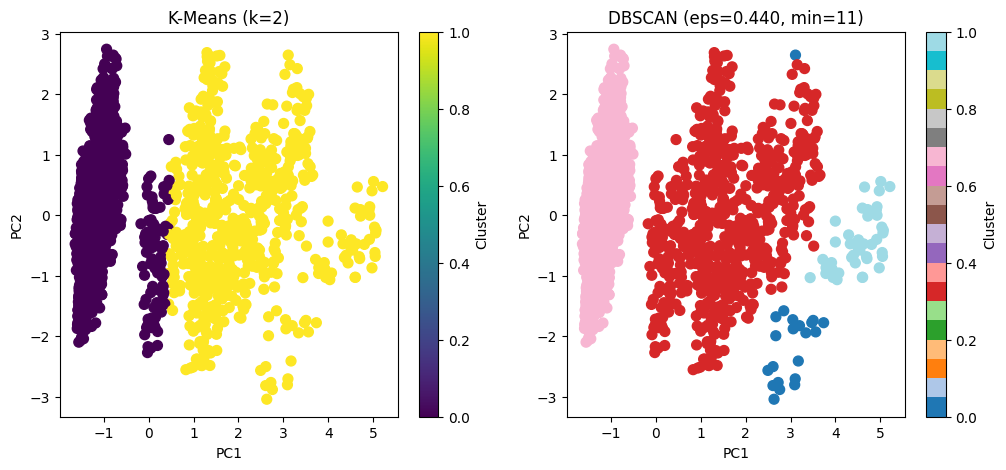

In [88]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# reducción de dimensionalidad con PCA
pca_df = pd.DataFrame(PCA(n_components=2, random_state=42).fit_transform(data_scaled), columns=['PC1','PC2'])
X = pca_df[['PC1','PC2']].values

#K-Means
# metodo del codo automático
inertia = [KMeans(n_clusters=k, random_state=42).fit(X).inertia_ for k in range(1,10)]
best_k = KneeLocator(range(1,10), inertia, curve='convex', direction='decreasing').knee
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels_k = kmeans.fit_predict(X)
silhouette_k = silhouette_score(X, labels_k)
pca_df['cluster_kmeans'] = labels_k

# dbscan
# búsqueda de parámetros eps y min_samples automática
# usando el método del codo en las distancias a los k-ésimos vecinos
# y optimizando el silhouette score
dims = X.shape[1]
best_score_db = -1

for min_s in range(dims*2, dims*6):
    nbrs = NearestNeighbors(n_neighbors=min_s).fit(X)
    distances = np.sort(nbrs.kneighbors(X)[0][:, -1])
    knee = KneeLocator(range(len(distances)), distances, curve='convex', direction='increasing')
    eps = distances[knee.knee] if knee.knee else 0.5
    labels_db = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X)
    mask = labels_db != -1
    if np.sum(mask) > 1:
        score_db = silhouette_score(X[mask], labels_db[mask])
        if score_db > best_score_db:
            best_score_db, best_eps, best_min, best_labels_db = score_db, eps, min_s, labels_db

pca_df['cluster_dbscan'] = best_labels_db

# resultados
print(f"K-Means: k={best_k}, Silhouette={silhouette_k:.3f}")
print(f"DBSCAN: eps={best_eps:.3f}, min_samples={best_min}, Silhouette={best_score_db:.3f}")
mejor_metodo = "K-Means" if silhouette_k >= best_score_db else "DBSCAN"
cluster_col = 'cluster_kmeans' if mejor_metodo == "K-Means" else 'cluster_dbscan'
print(f"Mejor método según Silhouette: {mejor_metodo}")

#visualización de los clústeres obtenidos por ambos métodos
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# K-Means
axes[0].scatter(X[:,0], X[:,1], c=labels_k, cmap='viridis', s=50)
axes[0].set_title(f'K-Means (k={best_k})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# DBSCAN
axes[1].scatter(X[:,0], X[:,1], c=best_labels_db, cmap='tab20', s=50)
axes[1].set_title(f'DBSCAN (eps={best_eps:.3f}, min={best_min})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axes[0], label='Cluster')
plt.colorbar(plt.cm.ScalarMappable(cmap='tab20'), ax=axes[1], label='Cluster')
plt.show()


## Paso 3: Descripción de los clústeres.

En este paso, intente comprender los clusters obtenidos. Utilice las técnicas vistas en el curso (análisis de medias, PCA, etc) para analizar los clusters, intentando interpretar el por qué de la clusterización que obtuvo.

**Nota**: Describa en la ventana siguiente los análisis que hizo, así como la conclusión a la que llegó. Incluya en la ventana siguiente los códigos finales utilizados para llegar a esta conclusión.


__Respuesta__:

In [89]:
summary = dataset_cleaned.copy()
summary[cluster_col] = pca_df[cluster_col].values

# Resumen estadístico por cluster
cluster_summary = summary.groupby(cluster_col).agg(['count','mean','std','min','max']).round(2)
cluster_sizes = summary[cluster_col].value_counts().sort_index()

print("\nTamaño de cada cluster:")
print(cluster_sizes)

print("\nResumen estadístico de cada cluster:")
display(cluster_summary)

# Interpretación automática
print("\nInterpretación de clusters:")
for cl in cluster_sizes.index:
    print(f"\nCluster {cl}:")
    print(f"Cantidad de clientes: {cluster_sizes[cl]}")
    for col in columns_to_scale:
        mean_val = cluster_summary.loc[cl][(col,'mean')]
        std_val = cluster_summary.loc[cl][(col,'std')]
        min_val = cluster_summary.loc[cl][(col,'min')]
        max_val = cluster_summary.loc[cl][(col,'max')]
        print(f" - {col}: media={mean_val}, std={std_val}, min={min_val}, max={max_val}")


Tamaño de cada cluster:
cluster_kmeans
0    1285
1     702
Name: count, dtype: int64

Resumen estadístico de cada cluster:


sale_hour                        age                            \
                   count   mean   std min max count   mean    std   min   max   
cluster_kmeans                                                                  
0                   1285  15.99  5.15   6  23  1285  41.92  13.63  18.0  64.0   
1                    702  16.05  5.10   6  23   702  40.30  13.67  18.0  64.0   

                ...  cogs                               total_sale           \
                ... count    mean     std    min    max      count     mean   
cluster_kmeans  ...                                                           
0               ...  1285   25.52   26.82   6.25  165.0       1285   106.33   
1               ...   702  222.42  125.55  75.00  620.0        702  1099.15   

                                       
                   std    min     max  
cluster_kmeans                         
0                90.43   25.0   600.0  
1               487.71  300.0  2000.0  

[2 rows x 30 columns]


Interpretación de clusters:

Cluster 0:
Cantidad de clientes: 1285
 - sale_hour: media=15.99, std=5.15, min=6.0, max=23.0
 - age: media=41.92, std=13.63, min=18.0, max=64.0
 - quantiy: media=2.4, std=1.15, min=1.0, max=4.0
 - price_per_unit: media=53.0, std=67.03, min=25.0, max=300.0
 - cogs: media=25.52, std=26.82, min=6.25, max=165.0
 - total_sale: media=106.33, std=90.43, min=25.0, max=600.0

Cluster 1:
Cantidad de clientes: 702
 - sale_hour: media=16.05, std=5.1, min=6.0, max=23.0
 - age: media=40.3, std=13.67, min=18.0, max=64.0
 - quantiy: media=2.73, std=1.07, min=1.0, max=4.0
 - price_per_unit: media=412.25, std=99.32, min=300.0, max=500.0
 - cogs: media=222.42, std=125.55, min=75.0, max=620.0
 - total_sale: media=1099.15, std=487.71, min=300.0, max=2000.0


## Paso 3: Descripción de los Clústeres

### Tamaño de los Clústeres
- **Cluster 0:** 1.285 clientes  
- **Cluster 1:** 702 clientes  

Cluster 0 representa la mayoría de los clientes, mientras que Cluster 1 corresponde a un grupo más pequeño.

### Resumen Estadístico y Análisis
| Variable | Cluster 0 (media ± std) | Cluster 1 (media ± std) | Interpretación |
|----------|------------------------|------------------------|----------------|
| **sale_hour** | 15.99 ± 5.15 | 16.05 ± 5.10 | Horario de compra similar, no diferencia los clusters |
| **age** | 41.92 ± 13.63 | 40.30 ± 13.67 | Edad comparable entre clusters |
| **quantiy** | 2.4 ± 1.15 | 2.73 ± 1.07 | Cluster 1 compra ligeramente más unidades |
| **price_per_unit** | 53.0 ± 67.03 | 412.25 ± 99.32 | Gran diferencia: Cluster 1 compra productos más caros |
| **cogs** | 25.52 ± 26.82 | 222.42 ± 125.55 | Costos más altos en Cluster 1 |
| **total_sale** | 106.33 ± 90.43 | 1099.15 ± 487.71 | Ventas totales mucho mayores en Cluster 1 |

### Interpretación
- **Cluster 0:** Clientes mayoritarios que compran productos económicos y en menor cantidad, generando ventas promedio bajas.  
- **Cluster 1:** Clientes minoritarios que compran productos caros y en cantidades algo mayores, generando ventas significativamente más altas, representando clientes de alto valor o “premium”.  
- **Variables diferenciadoras:** Principalmente `price_per_unit`, `cogs` y `total_sale`. Variables como `sale_hour` y `age` no contribuyen a la diferenciación de clusters.
